In [147]:
import warnings
from pathlib import Path


from datetime import datetime, timedelta, timezone
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

from statsmodels.tsa.api import SimpleExpSmoothing, Holt, ExponentialSmoothing
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

In [148]:
# Forecast horizon
FORECAST_START = '2026-04-20'
FORECAST_END = '2026-04-24'

TARGET_KEY = 'AVX'
TARGET_LABEL = "VIX"

FORECAST_DATES = pd.date_range(FORECAST_START, FORECAST_END, freq='D')
H = len(FORECAST_DATES)

In [149]:
def _default_range(days=3*365):
    end = datetime.now(timezone.utc).date()
    start = end - timedelta(days=days)
    return start.isoformat(), end.isoformat()


def _inclusive_end_for_yf(end_str):
    end_dt = datetime.strptime(end_str, "%Y-%m-%d").date()
    inclusive_plus = end_dt + timedelta(days=1)
    return inclusive_plus.isoformat()


def get_vix_df(start: str = None, end: str = None, days: int = 365, symbol: str = "^VIX") -> pd.DataFrame:
    """
    Fetch VIX adjusted close and return a DataFrame aligned to a daily calendar.

    Returns:
      pandas.DataFrame with columns ['date', symbol] where 'date' is dtype datetime64[ns].
    """
    if start is None or end is None:
        default_start, default_end = _default_range(days)
        start = start or default_start
        end = end or default_end

    try:
        _ = datetime.strptime(start, "%Y-%m-%d")
        _ = datetime.strptime(end, "%Y-%m-%d")
    except ValueError:
        raise ValueError("start and end must be in YYYY-MM-DD format")

    yf_end = _inclusive_end_for_yf(end)

    df = yf.download(symbol, start=start, end=yf_end, auto_adjust=True, progress=False)

    date_index = pd.date_range(start=start, end=end, freq="D")

    # If empty, return calendar with NaN floats
    if df is None or df.empty:
        out = pd.DataFrame({"date": date_index, symbol: np.nan})
        out["date"] = pd.to_datetime(out["date"])
        return out

    # If yfinance returned MultiIndex columns (e.g., ('Close', '^VIX')), flatten them
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = ["_".join([str(c) for c in col if c is not None]).strip() for col in df.columns.values]

    # Prefer 'Close' (auto_adjust=True makes it adjusted), fallback to 'Adj Close', else first numeric
    if "Close" in df.columns:
        series = df[["Close"]].rename(columns={"Close": symbol})
    elif "Adj Close" in df.columns:
        series = df[["Adj Close"]].rename(columns={"Adj Close": symbol})
    else:
        numeric_cols = df.select_dtypes(include="number").columns
        if len(numeric_cols) == 0:
            out = pd.DataFrame({"date": date_index, symbol: np.nan})
            out["date"] = pd.to_datetime(out["date"])
            return out
        first_col = numeric_cols[0]
        series = df[[first_col]].rename(columns={first_col: symbol})

    # Align to full calendar
    series.index = pd.to_datetime(series.index).normalize()
    aligned = series.reindex(date_index)
    aligned.index.name = "date"
    aligned = aligned.reset_index()
def get_vix_df(start: str = None, end: str = None, days: int = 365, symbol: str = "^VIX") -> pd.DataFrame:
    """
    Fetch VIX adjusted close and return a DataFrame aligned to a daily calendar.

    Returns:
      pandas.DataFrame with columns ['date', 'value'] where 'date' is dtype datetime64[ns].
    """
    if start is None or end is None:
        default_start, default_end = _default_range(days)
        start = start or default_start
        end = end or default_end

    try:
        _ = datetime.strptime(start, "%Y-%m-%d")
        _ = datetime.strptime(end, "%Y-%m-%d")
    except ValueError:
        raise ValueError("start and end must be in YYYY-MM-DD format")

    yf_end = _inclusive_end_for_yf(end)
    df = yf.download(symbol, start=start, end=yf_end, auto_adjust=True, progress=False)

    date_index = pd.date_range(start=start, end=end, freq="D")

    # If empty, return calendar with NaN floats under 'value'
    if df is None or df.empty:
        out = pd.DataFrame({"date": date_index, "VIX": np.nan})
        out["date"] = pd.to_datetime(out["date"])
        return out

    # Flatten MultiIndex columns if present
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = ["_".join([str(c) for c in col if c is not None]).strip() for col in df.columns.values]

    # Pick the appropriate column and rename to a temporary name
    if "Close" in df.columns:
        series = df[["Close"]].rename(columns={"Close": "tmp_value"})
    elif "Adj Close" in df.columns:
        series = df[["Adj Close"]].rename(columns={"Adj Close": "tmp_value"})
    else:
        numeric_cols = df.select_dtypes(include="number").columns
        if len(numeric_cols) == 0:
            out = pd.DataFrame({"date": date_index, "VIX": np.nan})
            out["date"] = pd.to_datetime(out["date"])
            return out
        first_col = numeric_cols[0]
        series = df[[first_col]].rename(columns={first_col: "tmp_value"})

    # Align to full calendar
    series.index = pd.to_datetime(series.index).normalize()
    aligned = series.reindex(date_index)
    aligned.index.name = "date"
    aligned = aligned.reset_index()

    # Finalize columns: rename tmp_value to 'value'
    aligned["date"] = pd.to_datetime(aligned["date"])
    aligned = aligned.rename(columns={"tmp_value": "VIX"})
    aligned["VIX"] = aligned["VIX"].astype(float)

    return aligned

In [150]:
df_live = get_vix_df(days = 365*3)
df_live.head(10)

,date,VIX
0,2023-03-25,NaN
1,2023-03-26,NaN
2,2023-03-27,20.600000
3,2023-03-28,19.969999
4,2023-03-29,19.120001
5,2023-03-30,19.020000
6,2023-03-31,18.700001
7,2023-04-01,NaN
8,2023-04-02,NaN
9,2023-04-03,18.549999


In [ ]:

def process_live_df(df: pd.DataFrame, date_col: str, target_col: str) -> pd.Series:
    # 1. Clean and convert types
    out = df[[date_col, target_col]].copy()
    out[date_col] = pd.to_datetime(out[date_col], errors='coerce')
    out[target_col] = pd.to_numeric(out[target_col], errors='coerce')
    
    # 2. Drop invalid rows and sort chronologically
    out = out.dropna(subset=[date_col]).sort_values(date_col)
    
    # 3. Set date as index and force a Daily frequency
    s = out.set_index(date_col)[target_col].asfreq('D')
    
    s = s.interpolate(method='time').ffill().bfill()
    
    return s


In [152]:
series = process_live_df(df_live, 'date', TARGET_LABEL)

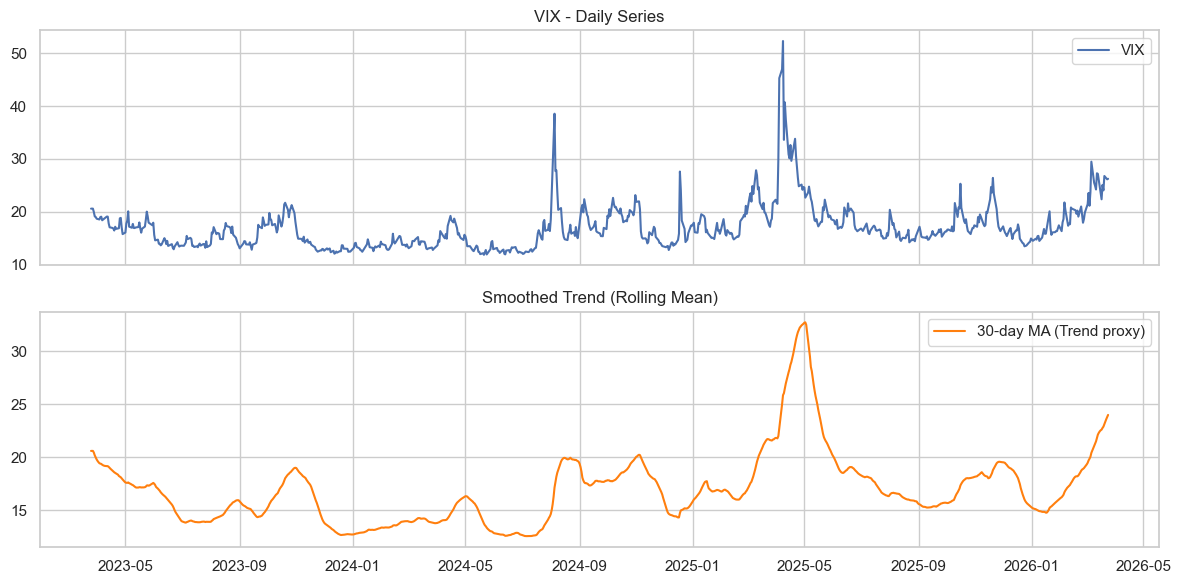

In [ ]:
# -----------------------------
# VISUALIZATION
# -----------------------------

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axes[0].plot(series.index, series.values, label=TARGET_LABEL)
axes[0].set_title(f'{TARGET_LABEL} - Daily Series')
axes[0].legend()

roll = series.rolling(30, min_periods=1).mean()
axes[1].plot(series.index, roll.values, color='tab:orange', label='30-day MA (Trend proxy)')
axes[1].set_title('Smoothed Trend (Rolling Mean)')
axes[1].legend()

plt.tight_layout()
plt.show()

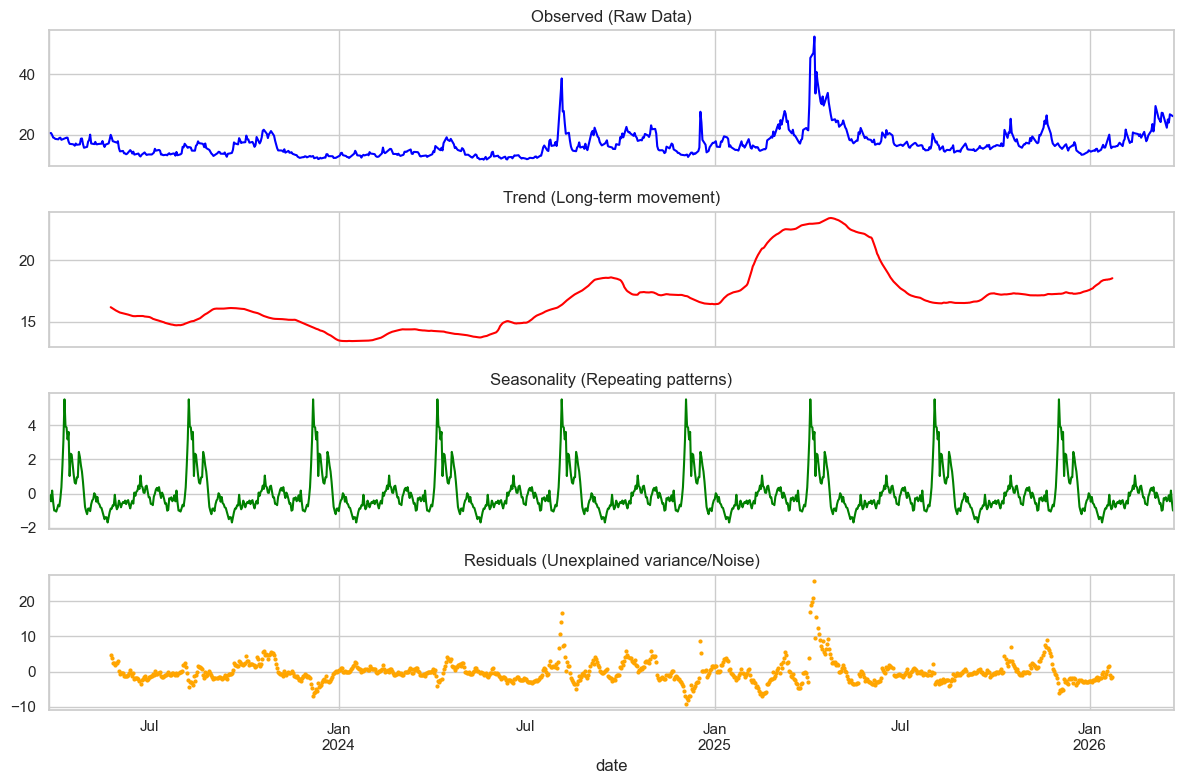

In [ ]:
# -----------------------------
# PLOT TREND/SEASONALITY/RESIDUALS
# -----------------------------


result = seasonal_decompose(series, model='additive', period=int(365/3))


fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(12, 8), sharex=True)


result.observed.plot(ax=ax1, color='blue')
ax1.set_title('Observed (Raw Data)')

# Trend: The long-term progression of the series, stripping away short-term fluctuations.
result.trend.plot(ax=ax2, color='red')
ax2.set_title('Trend (Long-term movement)')

# Seasonal: Repeating patterns that occur over a fixed period (e.g., annual cycles).
result.seasonal.plot(ax=ax3, color='green')
ax3.set_title('Seasonality (Repeating patterns)')

# Residual: What’s left after removing trend and seasonality; the "noise" or "shocks."
result.resid.plot(ax=ax4, color='orange', style='o', markersize=2)
ax4.set_title('Residuals (Unexplained variance/Noise)')

plt.tight_layout()
plt.show()

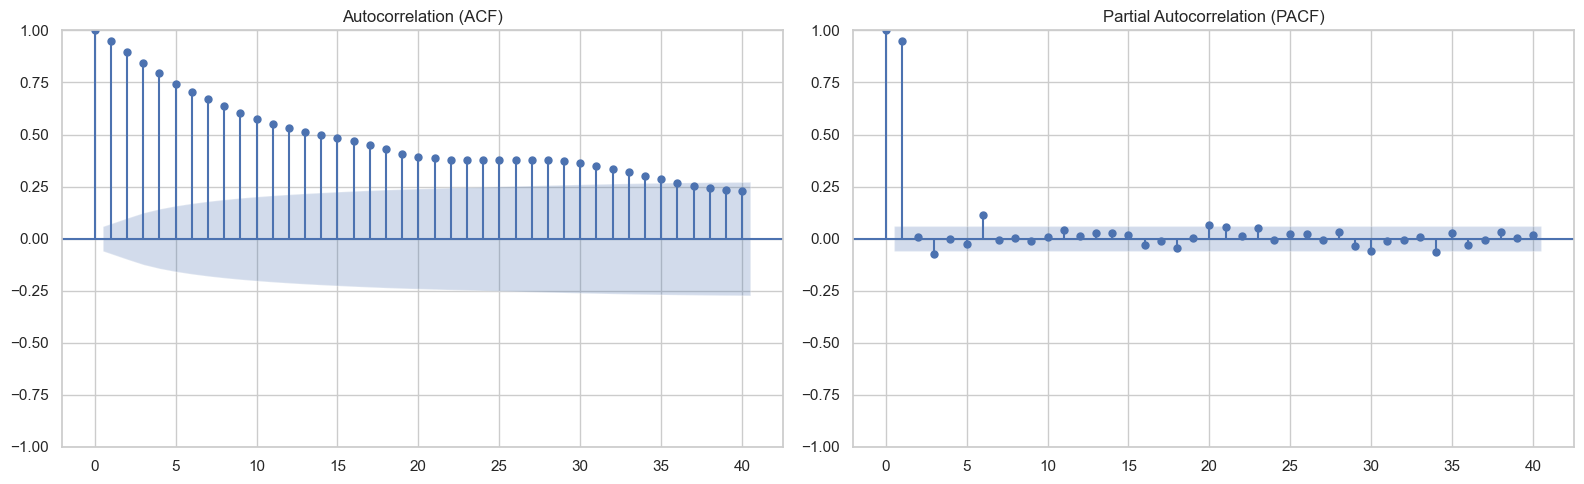

In [155]:
# -----------------------------
# PLOT ACF AND PACF
# -----------------------------

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ACF Plot
plot_acf(series, lags=40, ax=axes[0])
axes[0].set_title('Autocorrelation (ACF)')

# PACF Plot
plot_pacf(series, lags=40, ax=axes[1], method='ywm')
axes[1].set_title('Partial Autocorrelation (PACF)')

plt.tight_layout()
plt.show()

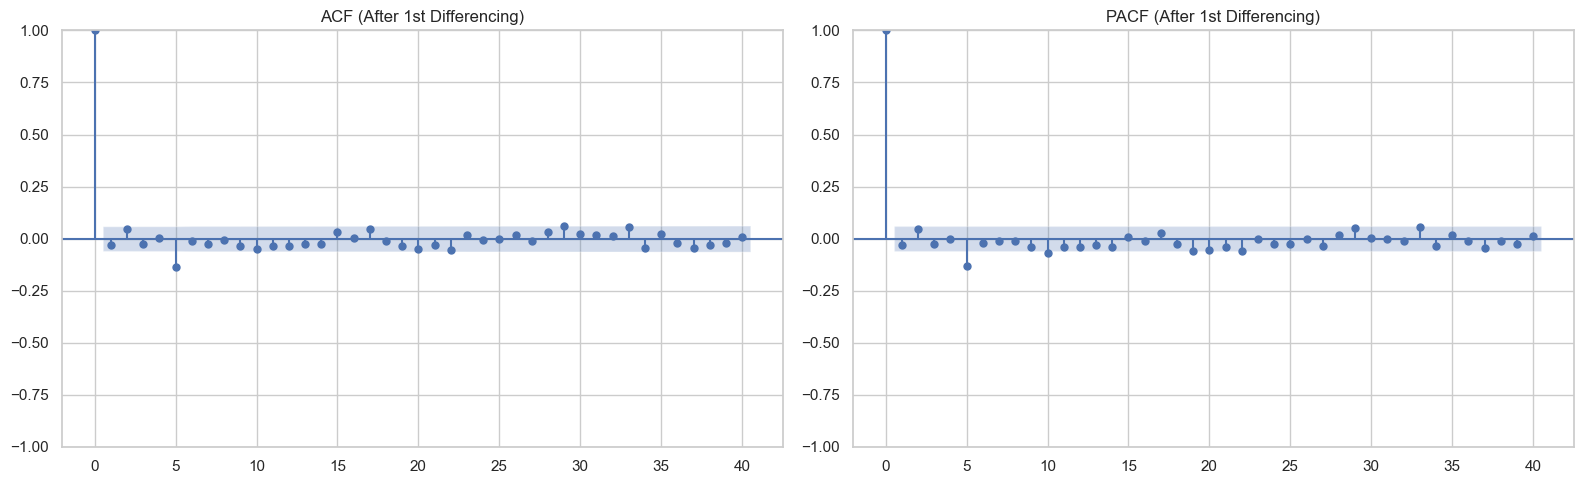

In [156]:
# -----------------------------
# PLOT ACF AND PACF AFTER FIRST ORDER DIFFERENCING
# -----------------------------

# This calculates the change from one day to the next
series_diff = series.diff().dropna()

# Plotting the results
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ACF Plot of Differenced Data
plot_acf(series_diff, lags=40, ax=axes[0])
axes[0].set_title('ACF (After 1st Differencing)')

# PACF Plot of Differenced Data
plot_pacf(series_diff, lags=40, ax=axes[1], method='ywm')
axes[1].set_title('PACF (After 1st Differencing)')

plt.tight_layout()
plt.show()

The Lag 0 Spike: This is always 1.0 (a variable is 100% correlated with itself).
The Cutoff at Lag 1: Because there are no significant spikes at lag 1, 2, or beyond, it means that yesterday's change has zero predictive power over today's change.
The Conclusion: "The first-order differenced VIX series is White Noise. This proves the original VIX follows a Random Walk process."


Since we differenced once => d = 1,
from the plots, PACF and ACF = 0,0

### Diagnostics: Testing for ARCH Effects
We observed massive residual spikes in 2022 and 2025. We tested if these "shocks" had a predictable memory (Volatility Clustering).

In [ ]:
SPLIT_RATIO = 0.8 # need to be rolling one that takes actual data after window is moved

import pandas as pd
import numpy as np



series = process_live_df(df_live, 'date', 'VIX')

# Define the split point (80% for training)
split_idx = int(len(series) * SPLIT_RATIO)

# Split the data
train = series.iloc[:split_idx]
test = series.iloc[split_idx:]

print(f"Total Observations: {len(series)}")
print(f"Training set: {len(train)} days (Ends: {train.index[-1].date()})")
print(f"Test set: {len(test)} days (Starts: {test.index[0].date()})")


Total Observations: 1096
Training set: 1085 days (Ends: 2026-03-13)
Test set: 11 days (Starts: 2026-03-14)


### ARIMA(0,1,0)
Because the ACF decayed slowly, we applied first-order differencing. Since the PACF of the differenced data showed no significant lags, our initial "naive" guess is an ARIMA(0,1,0). This assumes tomorrow's VIX is just today's value plus random noise.

In [158]:
from statsmodels.tsa.arima.model import ARIMA

# Fit the baseline to get residuals for diagnostics
# split_idx is assumed to be defined (80/20 split)
model_baseline = ARIMA(train, order=(0, 1, 0))
res_baseline = model_baseline.fit()
residuals = res_baseline.resid

### Testing for ARCH Effects (Heteroskedasticity)
We examine the residuals of our ARIMA(0,1,0) model. We want to know if the "size" of the errors in 2022 and 2025 is constant or if the variance changes over time.

ARCH Test p-value: 0.0000000000


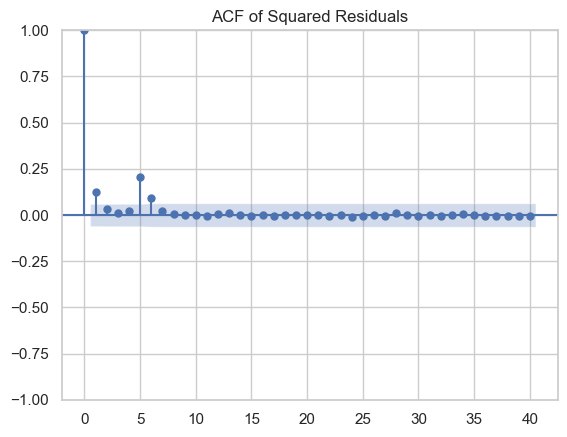

In [159]:
from statsmodels.stats.diagnostic import het_arch
from statsmodels.graphics.tsaplots import plot_acf

# Engle's ARCH Test
# H0: Constant Variance | H1: Changing Variance
lm_stat, p_val, f_stat, f_p_val = het_arch(residuals)
print(f"ARCH Test p-value: {p_val:.10f}")

# Visualizing "Memory" in Volatility
plot_acf(residuals**2, lags=40, title="ACF of Squared Residuals")
plt.show()

### Inference:
What we saw: The p-value was 0.000, proving the variance is NOT constant.

The Decision: However, the Squared ACF cut off at lag 0. This means the 2025 spikes are independent "jumps," not a persistent "cluster." Therefore, we reject GARCH (which requires clustering) and look at the distribution shape instead.

### Testing for "Fat Tails" (Kurtosis)
If the spikes are independent but extreme, the "Bell Curve" (Normal distribution) will fail. We test if the VIX has Fat Tails.

In [160]:
import scipy.stats as stats

# Normal distribution has a Kurtosis of 3
kurt = stats.kurtosis(residuals, fisher=False)
jb_stat, jb_p = stats.jarque_bera(residuals)

print(f"Kurtosis: {kurt:.2f}") # We observed ~17.98
print(f"Jarque-Bera p-value: {jb_p:.10f}")

Kurtosis: 72.30
Jarque-Bera p-value: 0.0000000000


### Inference
What we saw: A massive Kurtosis of 43.43.

The Decision: This proves the residuals are Leptokurtic. The 2025 shocks are structural "extreme events," not random accidents. A standard ARIMA is now mathematically disqualified.

### Fitting a Robust Distribution
We compare a Normal fit against a Student-t fit. The Student-t distribution has a parameter that allows for these heavy tails.

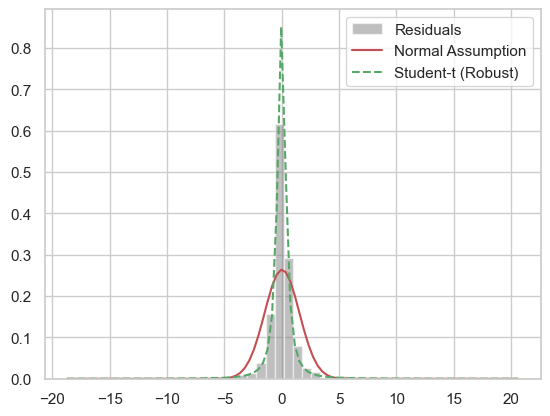

Degrees of Freedom (nu): 1.45


In [161]:
import numpy as np

# Visual Comparison
plt.hist(residuals, bins=50, density=True, alpha=0.5, color='gray', label='Residuals')

# Normal Fit (Red)
mu, std = stats.norm.fit(residuals)
x = np.linspace(min(residuals), max(residuals), 100)
plt.plot(x, stats.norm.pdf(x, mu, std), 'r-', label='Normal Assumption')

# Student-t Fit (Green)
t_params = stats.t.fit(residuals)
plt.plot(x, stats.t.pdf(x, *t_params), 'g--', label='Student-t (Robust)')

plt.legend()
plt.show()
print(f"Degrees of Freedom (nu): {t_params[0]:.2f}")

### Inference:
What we saw: The Student-t fit is far superior. The low Degrees of Freedom (1.65) confirms that the model must "expect" extreme 2025-style jumps to remain accurate.